In [ ]:
# Product & Customer Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\USER\Downloads\Data_Analysois_Projects\Sales_Business_analytics\train.csv")

In [3]:
## 1. Top Products by Sales

product_sales = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

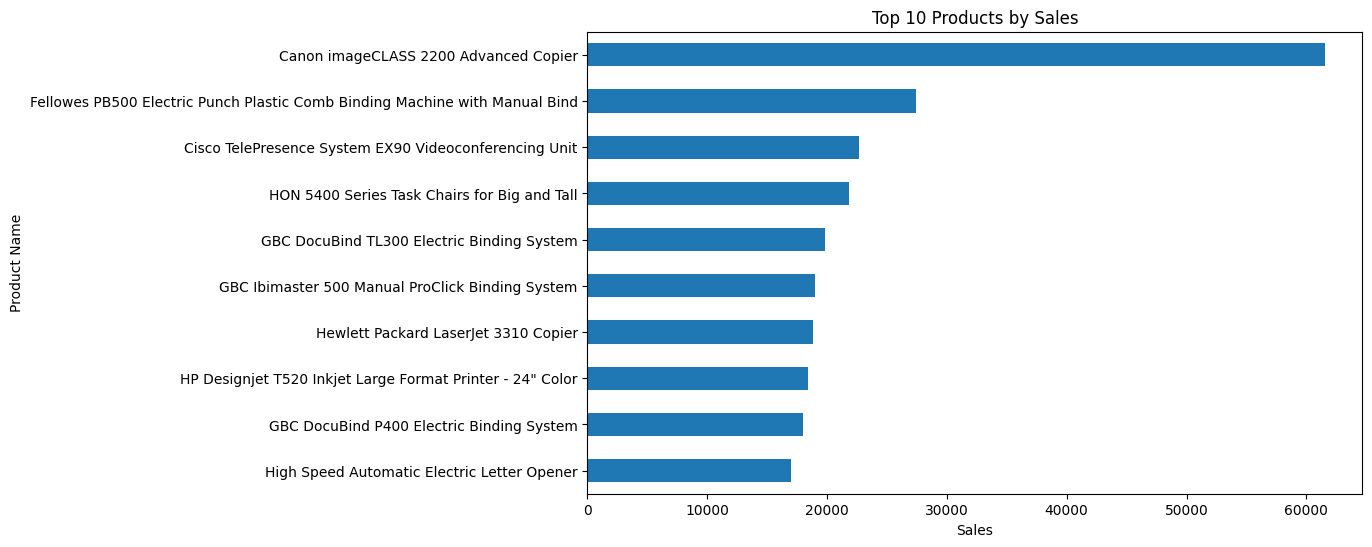

In [4]:
product_sales.head(10).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.show()

In [10]:
## 2. High-Sales but Low-Profit Products

product_summary = df.groupby("Product Name").agg(
    Sales=("Sales", "sum"),
)

product_summary[
    (product_summary["Sales"] > product_summary["Sales"].median()) &
].sort_values("Sales", ascending=False).head(20)

SyntaxError: invalid syntax (3529937356.py, line 9)

In [12]:
## 5. Customer Analysis

customer_summary = df.groupby(
    ["Customer ID", "Customer Name"]
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Orders=("Order ID", "nunique"),
).reset_index()

customer_summary.head()

,Customer ID,Customer Name,Total_Sales,Total_Orders
0,AA-10315,Alex Avila,5563.560,5
1,AA-10375,Allen Armold,1056.390,9
2,AA-10480,Andrew Allen,1790.512,4
3,AA-10645,Anna Andreadi,5086.935,6
4,AB-10015,Aaron Bergman,886.156,3


In [13]:
## 6. Top Customers

customer_summary.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

,Customer ID,Customer Name,Total_Sales,Total_Orders
700,SM-20320,Sean Miller,25043.050,5
741,TC-20980,Tamara Chand,19052.218,5
621,RB-19360,Raymond Buch,15117.339,6
730,TA-21385,Tom Ashbrook,14595.620,4
6,AB-10105,Adrian Barton,14473.571,10
434,KL-16645,Ken Lonsdale,14175.229,12
669,SC-20095,Sanjit Chand,14142.334,9
327,HL-15040,Hunter Lopez,12873.298,6
683,SE-20110,Sanjit Engle,12209.438,11
131,CC-12370,Christopher Conant,12129.072,5


In [14]:
## 7. Customer Segmentation

customer_summary["Customer_Segment"] = pd.cut(
    customer_summary["Total_Sales"],
    bins=[0, 1000, 5000, 10000, np.inf],
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

In [15]:
customer_summary["Customer_Segment"].value_counts()

Customer_Segment
Medium Value    501
Low Value       178
High Value       95
VIP              19
Name: count, dtype: int64